In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import MDAnalysis as mda

DATA = "../prod_traj/prod.data"    
DUMP = "../prod_traj/density.atom"   

u = mda.Universe(DATA, DUMP, topology_format="DATA",
                 format="LAMMPSDUMP")

/Users/bb24144/miniforge3/envs/Fresh/lib/python3.12/site-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt


In [ ]:
benzenes = u.select_atoms("type 0 1 2 3 4 5 6 7 8 9 10 11 12")
methanols = u.select_atoms("type 13 14 15 16 17 18")

print(benzenes.n_atoms)
print(methanols.n_atoms)

12
114


In [38]:
import scipp as sc
from kinisi.analyze import DiffusionAnalyzer


def com_diffusion(residues):
    p_params = {
        'specie_indices': sc.array(dims=['particle', 'atoms in particle'],
                      values=np.array([r.atoms.indices for r in residues])),
        'time_step': 1 * sc.Unit('fs'),
        'step_skip': 500 * sc.Unit('dimensionless'),
        'masses': sc.array(dims=['atoms in particle'], values=residues[0].atoms.masses)
    }

    return DiffusionAnalyzer.from_universe(u, **p_params)

In [ ]:
methanol_diffusion = com_diffusion(methanols.residues)
benzene_diffusion = com_diffusion(benzenes.residues)

fickian_start = 100.0  

for d in (methanol_diffusion, benzene_diffusion):
    d.diffusion(start_dt=sc.scalar(fickian_start, unit='ps'))

Reading Trajectory:   0%|          | 0/2001 [00:00<?, ?it/s]/Users/bb24144/miniforge3/envs/Fresh/lib/python3.12/site-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt
Likelihood Sampling: 100%|██████████| 1500/1500 [00:12<00:00, 119.47it/s]


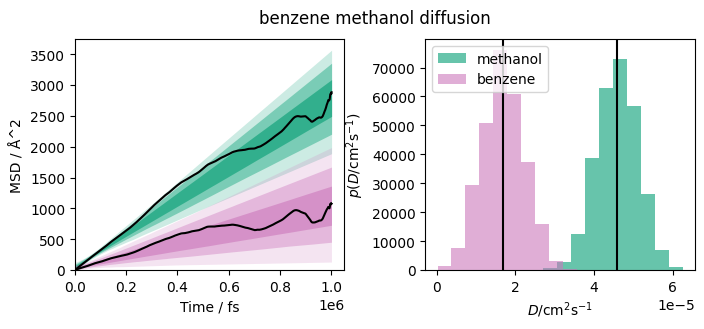

In [44]:
def uncertainty_plotter(kinisi_object, 
                        axis = None,
                        color = '#0173B2'):
    credible_intervals = [[16, 84], [2.5, 97.5], [0.15, 99.85]]
    alpha = [0.6, 0.4, 0.2]

    if axis == None:
        fig, axis = plt.subplots()

    axis.plot(kinisi_object.dt.values, kinisi_object.msd.values, 'k-')
    for i, ci in enumerate(credible_intervals):
        axis.fill_between(kinisi_object.dt.values,
                        *np.percentile(kinisi_object.distributions, ci, axis=1),
                        alpha=alpha[i],
                        color=color,
                        lw=0)
    axis.set_xlabel(f'Time / {kinisi_object.dt.unit}')
    axis.set_ylabel(f'MSD / {kinisi_object.msd.unit}')
    axis.set_xlim(0, None)
    axis.set_ylim(0, None)
    #plt.show()


c1 = "#029E73"
c2 = "#CC78BC"
colors = [c1,c2]

fig, ax = plt.subplots(1,2)
fig.set_size_inches(8,3)
fig.subplots_adjust(wspace=0.3)
fig.suptitle('benzene methanol diffusion')



for diff, color, label in zip([methanol_diffusion,benzene_diffusion], colors, ['methanol','benzene']):

    uncertainty_plotter(diff, ax[0], color = color)
    ax[1].hist(diff.D.values, density=True, color = color, label = label, alpha = 0.6)
    ax[1].axvline(diff.D.mean().values, c='k')


ax[1].set_xlabel('$D$/cm$^2$s$^{-1}$')
ax[1].set_ylabel('$p(D$/cm$^2$s$^{-1})$')
ax[1].legend()